In [1]:
import clickhouse_connect

client = clickhouse_connect.get_client(
    host='localhost',
    port=8123,
    username='default',
    password='Carrotito10.'
)

print("Conectado correctamente")

Conectado correctamente


In [2]:
client.command("SELECT 1")

1

In [3]:
import pandas as pd

query = """
SELECT
    formatDateTime(payment_date, '%Y-%m') AS mes,
    sum(amount) AS monto_total
FROM sakila_gold.fact_rentals
GROUP BY mes
ORDER BY mes
"""

df = client.query_df(query)
df

,mes,monto_total
0,2005-05,4823.44
1,2005-06,9629.89
2,2005-07,28368.91
3,2005-08,24070.14
4,2006-02,514.18


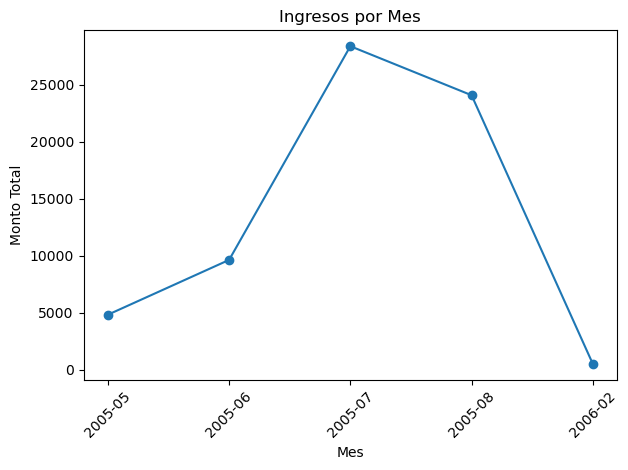

In [4]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df["mes"], df["monto_total"], marker="o")
plt.xticks(rotation=45)
plt.title("Ingresos por Mes")
plt.xlabel("Mes")
plt.ylabel("Monto Total")
plt.tight_layout()
plt.show()

In [5]:
query_top = """
SELECT
    customer_id,
    sum(amount) AS total
FROM sakila_gold.fact_rentals
GROUP BY customer_id
ORDER BY total DESC
LIMIT 10
"""

df_top = client.query_df(query_top)
df_top

,customer_id,total
0,526,221.55
1,148,216.54
2,144,195.58
3,137,194.61
4,178,194.61
5,459,186.62
6,469,177.60
7,468,175.61
8,236,175.58
9,181,174.66


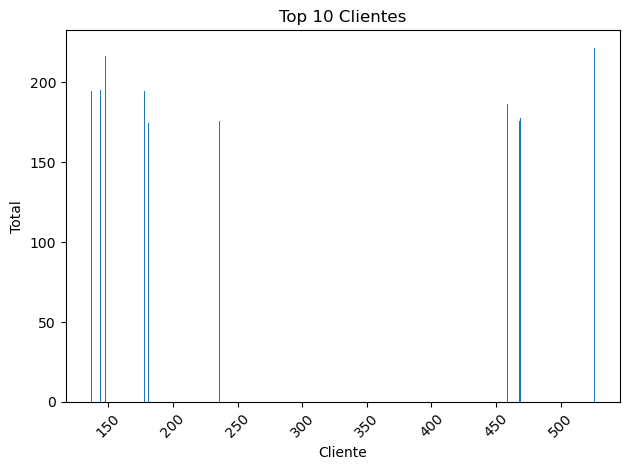

In [6]:
plt.figure()
plt.bar(df_top["customer_id"], df_top["total"])
plt.title("Top 10 Clientes")
plt.xlabel("Cliente")
plt.ylabel("Total")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()